# **Day 1: What is Machine Learning?**
*Module 1 - Foundations and Tools*

Welcome to **100 Days of Machine Learning**. Over 100 days this course takes us from **zero** to **research-level ML**. It ends with **seven complete, publication-ready Remote Sensing (RS) projects**.

**Machine Learning (ML)** is the science of getting computers to **learn rules from examples** instead of being explicitly programmed.

| | Input | Output |
|---|---|---|
| **Traditional programming** | Rules + Data | Answers |
| **Machine Learning** | Data + Answers (examples) | **Rules** (a model) |

> Machine learning means letting a computer find the rule from examples instead of writing the rule ourselves. We show it many inputs together with the correct answers, and it learns a pattern that also works on new inputs.
>
> *Example:* To recognise water in a satellite image, we do not write "water is dark in NIR" by hand. We give the computer 1,000 pixels labelled water or not-water, and it discovers the rule (and its exceptions) by itself.

## **1. Our First Machine Learning Model**
Suppose we want to detect **water** in a satellite image using the near-infrared (NIR) reflectance of a pixel. Water absorbs NIR strongly, so its NIR value is low.

- **Traditional approach:** an expert writes the rule `water if NIR < 0.08`.
- **ML approach:** we give the computer labelled examples and it **finds the rule itself**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
nir_water = rng.normal(0.04, 0.02, 50).clip(0.005)   # 50 water pixels
nir_land = rng.normal(0.25, 0.07, 50).clip(0.05)     # 50 land pixels
X = np.concatenate([nir_water, nir_land]).reshape(-1, 1)   # features: 2D (samples x features)
y = np.array([1] * 50 + [0] * 50)                         # labels: 1 = water, 0 = land

# Traditional programming: a hand-written rule
rule_pred = (X[:, 0] < 0.08).astype(int)
print("Hand-written rule accuracy:", (rule_pred == y).mean())

Hand-written rule accuracy: 0.99


In [2]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=1)   # 1. choose a model
model.fit(X, y)                               # 2. learn from examples
print(f"Learned rule: water if NIR <= {model.tree_.threshold[0]:.3f}")
print("Model accuracy:", model.score(X, y))   # 3. evaluate
print("Prediction for NIR = 0.03 and 0.30:", model.predict([[0.03], [0.30]]))   # 4. predict new data

Learned rule: water if NIR <= 0.107
Model accuracy: 1.0
Prediction for NIR = 0.03 and 0.30: [1 0]


- `fit(X, y)` is where **learning** happens. `X` holds the **features** (inputs), `y` the **labels** (answers).
- The model found the threshold by itself. With 1 feature a human can do this too. With **200 features** (e.g. 10 bands x 20 dates) no human can, but ML can.

## **2. Types of Machine Learning**

| Type | Data given | Goal | Examples |
|---|---|---|---|
| **Supervised - classification** | Inputs + **class labels** | Predict a category | Spam filter, disease diagnosis, land-cover map |
| **Supervised - regression** | Inputs + **numbers** | Predict a quantity | House price, crop yield, biomass |
| **Unsupervised** | Inputs only | Find structure | Customer segments, image clustering, anomaly detection |
| **Semi-supervised** | Few labels + many unlabelled | Use unlabelled data to help | Medical images with few annotations |
| **Self-supervised** | Unlabelled data, labels made from the data itself | Learn representations | GPT (predict next word), satellite foundation models |
| **Reinforcement learning** | Rewards from an environment | Learn actions | Games, robotics, resource management |

Let us see the first three on simple 2D data.

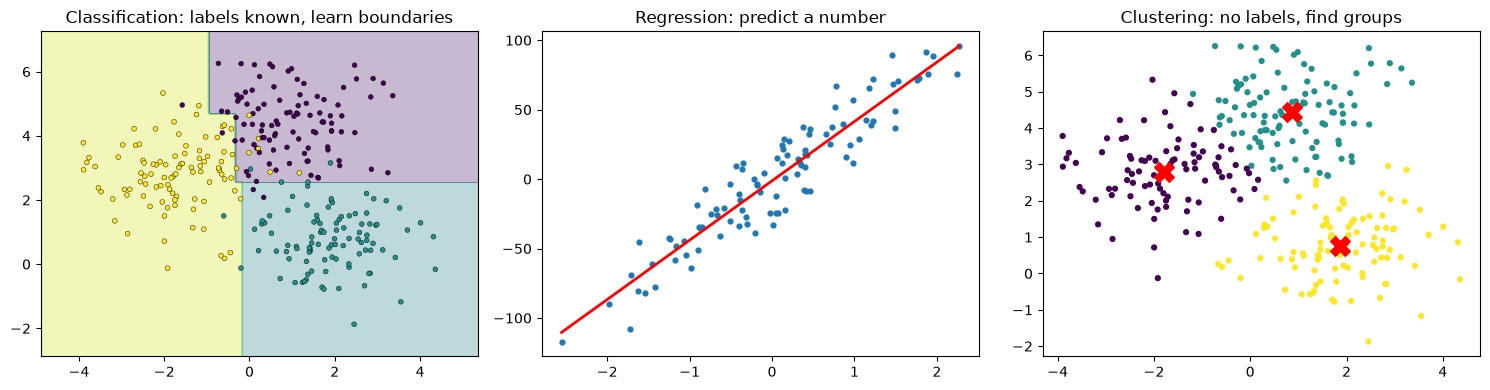

In [3]:
from sklearn.datasets import make_blobs, make_regression
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

Xc, yc = make_blobs(n_samples=300, centers=3, random_state=0)
clf = DecisionTreeClassifier(max_depth=3).fit(Xc, yc)
xx, yy = np.meshgrid(np.linspace(Xc[:, 0].min() - 1, Xc[:, 0].max() + 1, 200),
                     np.linspace(Xc[:, 1].min() - 1, Xc[:, 1].max() + 1, 200))
axes[0].contourf(xx, yy, clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape), alpha=0.3)
axes[0].scatter(Xc[:, 0], Xc[:, 1], c=yc, s=12, edgecolor="k", lw=0.3)
axes[0].set_title("Classification: labels known, learn boundaries")

Xr, yr = make_regression(n_samples=100, n_features=1, noise=15, random_state=0)
reg = LinearRegression().fit(Xr, yr)
axes[1].scatter(Xr, yr, s=12)
xs = np.linspace(Xr.min(), Xr.max(), 50).reshape(-1, 1)
axes[1].plot(xs, reg.predict(xs), "r", lw=2)
axes[1].set_title("Regression: predict a number")

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xc)
axes[2].scatter(Xc[:, 0], Xc[:, 1], c=km.labels_, s=12, cmap="viridis")
axes[2].scatter(*km.cluster_centers_.T, c="red", marker="X", s=200)
axes[2].set_title("Clustering: no labels, find groups")
plt.tight_layout(); plt.show()

## **3. Key Vocabulary**

| Term | Meaning |
|---|---|
| **Sample / instance** | One example (one row): a pixel, a patient, a house |
| **Feature / attribute** | One input variable (one column): NIR, age, area |
| **Label / target** | The answer we want to predict |
| **Model** | A function $f(x)$ with adjustable **parameters** |
| **Training** | Adjusting parameters so predictions match labels |
| **Hyperparameter** | A setting chosen *before* training (e.g. tree depth) |
| **Loss** | A number that measures how wrong the model is |
| **Generalisation** | Performing well on **new, unseen** data (the real goal) |
| **Overfitting** | Memorising training data, failing on new data |

## **4. The Machine Learning Workflow**
Every ML project, from a Kaggle competition to a journal paper, follows these steps:

In [4]:
workflow = [
    ("1. Define the problem", "Task, success metric, constraints", "Day 1, 15"),
    ("2. Collect data", "Databases, sensors, satellites, surveys", "Day 4, 86-87"),
    ("3. Explore (EDA)", "Distributions, correlations, quality", "Day 5-6"),
    ("4. Prepare data", "Cleaning, missing values, encoding, scaling", "Day 15-21"),
    ("5. Choose models", "Linear, trees, ensembles, neural nets", "Day 22-76"),
    ("6. Train + validate", "Cross-validation, tuning", "Day 40-42"),
    ("7. Evaluate on test set", "Metrics, uncertainty, statistics", "Day 25, 28, 77"),
    ("8. Interpret", "Feature importance, SHAP", "Day 43-45"),
    ("9. Deploy + monitor", "APIs, drift detection, MLOps", "Day 81-84"),
    ("10. Communicate", "Figures, papers, reports", "Day 99-100"),
]
for step, what, days in workflow:
    print(f"{step:<26}{what:<45}{days}")

1. Define the problem     Task, success metric, constraints            Day 1, 15
2. Collect data           Databases, sensors, satellites, surveys      Day 4, 86-87
3. Explore (EDA)          Distributions, correlations, quality         Day 5-6
4. Prepare data           Cleaning, missing values, encoding, scaling  Day 15-21
5. Choose models          Linear, trees, ensembles, neural nets        Day 22-76
6. Train + validate       Cross-validation, tuning                     Day 40-42
7. Evaluate on test set   Metrics, uncertainty, statistics             Day 25, 28, 77
8. Interpret              Feature importance, SHAP                     Day 43-45
9. Deploy + monitor       APIs, drift detection, MLOps                 Day 81-84
10. Communicate           Figures, papers, reports                     Day 99-100


# **Part 2: Going Deeper**

## **5. A Formal Definition**

Tom Mitchell (1997): *A program learns from **experience E** with respect to a **task T** and **performance measure P** if its performance at T, measured by P, improves with E.*

Mathematically, we choose a function $f$ from a **hypothesis space** $\mathcal{H}$ (all thresholds, all trees, all neural networks...) that makes the **loss** $L(y, f(x))$ small. We cannot see all possible data, so we minimise the average loss on the $n$ training samples, called the **empirical risk**:

$$\hat{R}(f) = \frac{1}{n}\sum_{i=1}^{n} L\big(y_i, f(x_i)\big), \qquad \hat{f} = \arg\min_{f \in \mathcal{H}} \hat{R}(f)$$

This is **Empirical Risk Minimisation (ERM)**, the principle behind almost every algorithm in this course. Let us do ERM by brute force over the hypothesis space "water if NIR < t".

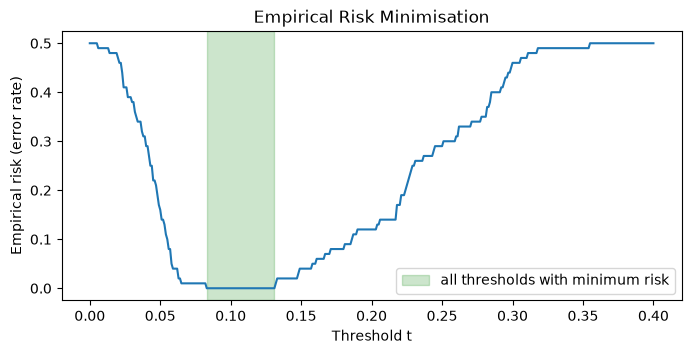

Thresholds from 0.083 to 0.131 all reach the minimum training error 0.00


In [5]:
thresholds = np.linspace(0, 0.4, 401)
risk = np.array([((X[:, 0] < t).astype(int) != y).mean() for t in thresholds])   # 0-1 loss

plt.figure(figsize=(8, 3.5))
plt.plot(thresholds, risk)
plt.xlabel("Threshold t"); plt.ylabel("Empirical risk (error rate)")
zero = thresholds[risk == risk.min()]
plt.axvspan(zero.min(), zero.max(), color="green", alpha=0.2, label="all thresholds with minimum risk")
plt.legend(); plt.title("Empirical Risk Minimisation"); plt.show()
print(f"Thresholds from {zero.min():.3f} to {zero.max():.3f} all reach the minimum training error {risk.min():.2f}")

Many thresholds give the same training error. Training data alone cannot choose between them. The tree chose the **midpoint**. A preference like this is called **inductive bias**.

## **6. Generalisation, Inductive Bias and No Free Lunch**

What we really care about is the **true risk** on future data, $R(f) = \mathbb{E}_{(x,y)\sim P}[L(y, f(x))]$. The difference $R(f) - \hat{R}(f)$ is the **generalisation gap**. Theory guarantees a small gap only when training and future data are **i.i.d.** (independent and identically distributed) samples of the same distribution.

Every algorithm makes assumptions (**inductive bias**) to generalise beyond its training points. The **No Free Lunch theorem** (Wolpert, 1996) says no algorithm is best for every problem. So we always **compare several models**.

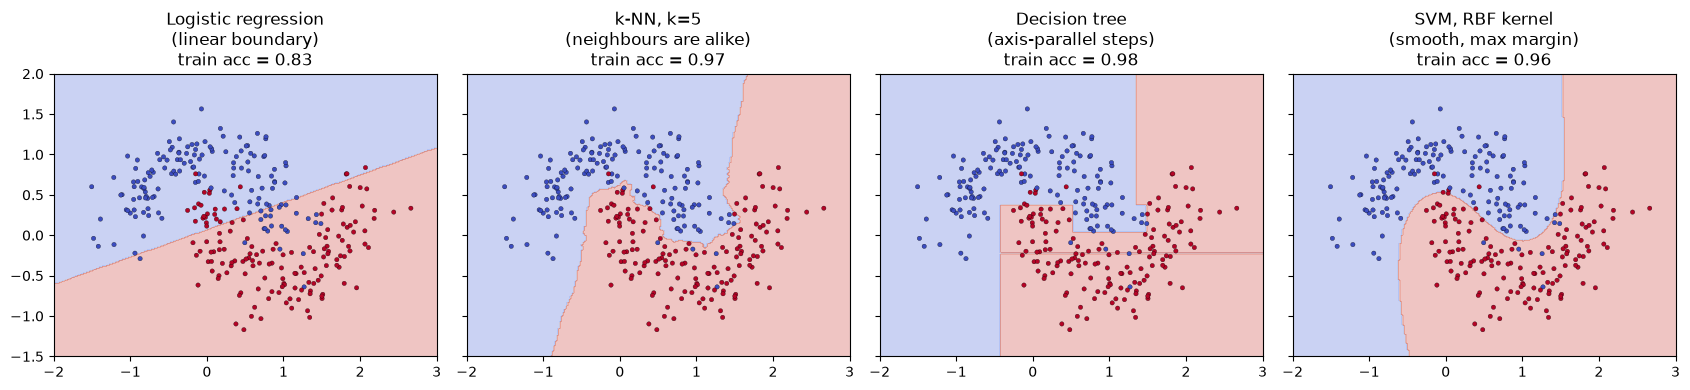

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.25, random_state=0)
models = {"Logistic regression\n(linear boundary)": LogisticRegression(),
          "k-NN, k=5\n(neighbours are alike)": KNeighborsClassifier(5),
          "Decision tree\n(axis-parallel steps)": DecisionTreeClassifier(max_depth=5),
          "SVM, RBF kernel\n(smooth, max margin)": SVC()}
xx, yy = np.meshgrid(np.linspace(-2, 3, 250), np.linspace(-1.5, 2, 250))
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    m.fit(Xm, ym)
    ax.contourf(xx, yy, m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape), alpha=0.3, cmap="coolwarm")
    ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="coolwarm", s=10, edgecolor="k", lw=0.2)
    ax.set_title(f"{name}\ntrain acc = {m.score(Xm, ym):.2f}")
plt.tight_layout(); plt.show()

Same data, four inductive biases, four different boundaries. Far from the data the models **disagree**: predictions there come from assumptions, not evidence (**extrapolation**).

## **7. Generalisation in Action: Distribution Shift**

When the i.i.d. assumption breaks (new region, new season, new hospital, new sensor), accuracy can collapse. Below, the water model meets **turbid (muddy) water**, whose NIR is higher.

In [7]:
clear = rng.normal(0.04, 0.02, 50).clip(0.005)
turbid = rng.normal(0.12, 0.03, 50).clip(0.03)
land = rng.normal(0.25, 0.07, 100).clip(0.05)
X_new = np.concatenate([clear, turbid, land]).reshape(-1, 1)
y_new = np.array([1] * 100 + [0] * 100)
print(f"Accuracy on training-like data : {model.score(X, y):.2f}")
print(f"Accuracy in the new region     : {model.score(X_new, y_new):.2f}")
print(f"Turbid water correctly detected: {(model.predict(turbid.reshape(-1, 1)) == 1).mean():.2f}")

Accuracy on training-like data : 1.00
Accuracy in the new region     : 0.82
Turbid water correctly detected: 0.34


The model is not "wrong". It is used **outside the conditions it learned from**. Days 79 (domain adaptation) and 88 (area of applicability) deal with this.

## **8. The 100-Day Roadmap**

| Days | Module | Topics |
|---|---|---|
| 1-8 | **Foundations and Tools** | Python stack, NumPy, Pandas, visualisation, EDA, linear algebra, calculus |
| 9-14 | **Probability, Statistics, Optimisation** | Distributions, inference, hypothesis tests, information theory, gradient descent, MLE/MAP |
| 15-21 | **Data Preparation** | scikit-learn API, leakage, missing values, scaling, encoding, feature engineering, pipelines, imbalance |
| 22-26 | **Regression** | OLS, gradient descent, regularisation, diagnostics, GLMs, quantile regression |
| 27-34 | **Classification** | Logistic regression, metrics, calibration, kNN, Naive Bayes, SVM, trees, multi-label |
| 35-40 | **Ensembles** | Bagging, Random Forest, boosting, XGBoost/LightGBM/CatBoost, stacking, cross-validation |
| 41-45 | **Tuning and Explainability** | Bayesian optimisation, model comparison, feature selection, PDP/ALE, SHAP |
| 46-52 | **Unsupervised** | K-Means, DBSCAN, GMM/EM, PCA, t-SNE/UMAP, anomaly detection, recommenders |
| 53-57 | **Probabilistic and Time Series** | Bayesian ML, MCMC, Gaussian processes, ARIMA, forecasting, semi-supervised |
| 58-66 | **Deep Learning** | NN from scratch, PyTorch, CNN, ResNet, transfer learning, U-Net, RNN/LSTM |
| 67-76 | **Advanced Deep Learning** | Transformers, NLP, ViT, contrastive learning, VAE, GAN, diffusion, GNN, RL, LLMs |
| 77-85 | **Trustworthy ML and MLOps** | Uncertainty, conformal prediction, fairness, domain adaptation, PINNs, deployment, drift, big data, capstone |
| 86-100 | **Remote Sensing ML Publication Projects** | RS data, GEE, spatial CV, 7 complete projects, reproducibility, writing the paper |

## **Practice Problems**
1. Name two problems from our own field. Is each classification, regression or clustering?
2. Change the land NIR values to `rng.normal(0.10, 0.05, 50)` (wet soil). Retrain the model. What happens to the threshold and accuracy?
3. Write down T, E and P (Mitchell's definition) for a spam filter.
4. *(Advanced)* Retrain the water model on `X_new, y_new`. What threshold does it learn? What does this teach us about collecting training data?

In [8]:
# Solution 2
nir_wet = rng.normal(0.10, 0.05, 50).clip(0.01)
X2 = np.concatenate([nir_water, nir_wet]).reshape(-1, 1)
m2 = DecisionTreeClassifier(max_depth=1).fit(X2, y)
print(f"Threshold: {m2.tree_.threshold[0]:.3f}, accuracy: {m2.score(X2, y):.2f}  -> overlapping classes need more features")

# Solution 4
m4 = DecisionTreeClassifier(max_depth=1).fit(X_new, y_new)
print(f"Threshold learned in the new region: {m4.tree_.threshold[0]:.3f} (was {model.tree_.threshold[0]:.3f})")
print("Training data must cover ALL conditions the model will meet.")

Threshold: 0.065, accuracy: 0.89  -> overlapping classes need more features
Threshold learned in the new region: 0.172 (was 0.107)
Training data must cover ALL conditions the model will meet.


**Solution 3:** T = label an e-mail as spam / not spam; E = a set of e-mails labelled by users; P = accuracy (or F1) on new e-mails.

## **Key References**
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- Samuel, A. L. (1959). Some studies in machine learning using the game of checkers. *IBM Journal of Research and Development*, 3(3), 210-229.
- Wolpert, D. H. (1996). The lack of a priori distinctions between learning algorithms. *Neural Computation*, 8(7), 1341-1390.
- Breiman, L. (2001). Statistical modeling: The two cultures. *Statistical Science*, 16(3), 199-231.
- Domingos, P. (2012). A few useful things to know about machine learning. *Communications of the ACM*, 55(10), 78-87.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.